In [1]:
from __future__ import print_function
#%matplotlib inline
#import argparse
import os
import random
import time
import torch
import torch.nn as nn
#import torch.nn.parallel
#import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib.animation as animation
#from IPython.display import HTML
import torchvision
import torchvision.transforms as transforms
#from torch.autograd import Variable
import torch.nn.functional as F

# Set random seed for reproducibility
randomSeed = 10
#manualSeed = random.randint(1, 10000) # use if you want new results
#print("Random Seed: ", manualSeed)
random.seed(randomSeed)
#torch.manual_seed(manualSeed)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:


dataroot = "./data"  	# root directory for dataset
workers = 2 		# number of workers for dataloader
batch_size = 128 	# batch size
image_size = 32		# image size
nc = 1   		# image channels, 3 for color
nz = 100 		# size of z noise vector
ngf = 128		# size of feature maps in generator
ndf = 128		# size of feature maps in discriminator
lr = 0.0002		# learning rate
beta1 = 0.5		# beta1 hyperparameter for Adam optimizers
ngpu = 1		# number of GPUs available. Use 0 for CPU mode.

num_epochs = 20		# number of training epochs


In [4]:
# Create the dataset
transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5,), (0.5,))])
dataset = torchvision.datasets.MNIST(root=dataroot, train=True,
                                       download=True, transform=transform)

# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# Decide device to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")


100%|██████████| 9912422/9912422 [00:00<00:00, 118866198.10it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 92966764.25it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 74610719.22it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 18861909.67it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [5]:
# Generator Code

class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.deconv1_1 = nn.ConvTranspose2d(100,ngf*2, 4, 1, 0)
        self.deconv1_1_bn = nn.BatchNorm2d(ngf*2)
        self.deconv1_2 = nn.ConvTranspose2d(10, ngf*2, 4, 1, 0)
        self.deconv1_2_bn = nn.BatchNorm2d(ngf*2)
        self.deconv2 = nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1)
        self.deconv2_bn = nn.BatchNorm2d(ngf*2)
        self.deconv3 = nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1)
        self.deconv3_bn = nn.BatchNorm2d(ngf)
        self.deconv4 = nn.ConvTranspose2d(ngf, 1, 4, 2, 1)

    def forward(self, input, label):
        x = F.relu(self.deconv1_1_bn(self.deconv1_1(input)))
        y = F.relu(self.deconv1_2_bn(self.deconv1_2(label)))
        x = torch.cat([x,y],1)
        x = F.relu(self.deconv2_bn(self.deconv2(x)))
        x = F.relu(self.deconv3_bn(self.deconv3(x)))
        x = torch.tanh(self.deconv4(x))

        return x


In [6]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.conv1_1 = nn.Conv2d(1,int(ndf/2), 4, 2, 1)
        self.conv1_2 = nn.Conv2d(10, int(ndf/2), 4, 2, 1)
        self.conv2 = nn.Conv2d(ndf, ndf*2, 4, 2, 1)
        self.conv2_bn = nn.BatchNorm2d(ndf*2)
        self.conv3 = nn.Conv2d(ndf*2, ndf*4, 4, 2, 1)
        self.conv3_bn = nn.BatchNorm2d(ndf*4)
        self.conv4 = nn.Conv2d(ndf*4, 1, 4, 1, 0)


    def forward(self, input, label):
        x = F.leaky_relu(self.conv1_1(input), 0.2)
        y = F.leaky_relu(self.conv1_2(label), 0.2)
        x = torch.cat([x,y], 1)
        x = F.leaky_relu(self.conv2_bn(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.conv3_bn(self.conv3(x)), 0.2)
        x = torch.sigmoid(self.conv4(x))
        return x


In [7]:
# weights initialization called by Gnet and Dnet
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02) #(..., 1.0,0.02)
        nn.init.constant_(m.bias.data, 0)


In [20]:
# Create the generator
Gnet = Generator(ngpu).to(device)
Gnet.apply(weights_init)

# Create the Discriminator
Dnet = Discriminator(ngpu).to(device)
Dnet.apply(weights_init)


Discriminator(
  (conv1_1): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv1_2): Conv2d(10, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv2_bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv3_bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
)

In [21]:
# Instantiate BCELoss function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
#fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(Dnet.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(Gnet.parameters(), lr=lr, betas=(beta1, 0.999))


In [22]:
# label preprocess
onehot = torch.zeros(10, 10)
onehot = onehot.scatter_(1, torch.LongTensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]).view(10,1), 1).view(10, 10, 1, 1)
fill = torch.zeros([10, 10, image_size, image_size])
for i in range(10):
    fill[i, i, :, :] = 1
#onehot [10,10,1,1]:  10 one-hot vectors, each for one digit
# fill [10,10,32,32]: 10 condition images,
#                     each image has 10 feature maps with one-hot feature map.


In [23]:
# Training Loop

# Lists to monitor the training progress
img_list = []
G_losses = []
D_losses = []
num_epochs = 10
print("Starting Training Loop...")


for epoch in range(num_epochs):
    # For each epoch
    y_real_ = torch.ones(batch_size)
    y_fake_ = torch.zeros(batch_size)
    y_real_ = y_real_.to(device)
    y_fake_ = y_fake_.to(device)

    # y_real_= [1,1,1,1,...,1]
    # y_fake_= [0,0,0,0,...,0]

    for i, data in enumerate(dataloader, 0):

        # For each batch
        # ------------------------------------------------------
        # (1) Update D network: maximize log(D(x))+log(1-D(G(z)))
        # -------------------------------------------------------

        # (1) (A)Train with all-real image batch
        Dnet.zero_grad()
        real_imgs= data[0].to(device) #data[0] are images for the batch
        b_s = real_imgs.size(0)        #b_s is batch size
        label=torch.full((b_s,),real_label,dtype=torch.float,device=device)
        if b_s != batch_size:
            y_real_ = torch.ones(b_s)
            y_fake_ = torch.zeros(b_s)
            y_real_ = y_real_.to(device)
            y_fake_ = y_fake_.to(device)

        y_fill_ = fill[data[1]]  # y_fill_ : [b_size, 10, 32, 32]
                                 # data[1]: labels
        y_fill_ = y_fill_.to(device)

        # Calculate the output of D
        output = Dnet(real_imgs, y_fill_).view(-1)
        # Calculate loss on the real batch
        errD_real = criterion(output, y_real_)
        # Calculate gradients for D
        errD_real.backward()
        D_x = output.mean().item()

        # (1) (B) Train with all-fake image batch

        # Generate batch of latent vectors
        # Gnet inputs: z_ is random noise,
        #              y_label_ is random label in one-hot vector
        # Dnet inputs: fake from Gnet, and y_fill_
        z_ = torch.randn((b_s, 100)).view(-1, 100, 1, 1)
        # z_ is [b_size, 100, 1, 1]
        y_ = (torch.rand(b_s, 1) * 10).type(torch.LongTensor).squeeze()
        # y_ is [b_size] and is random labels
        y_label_ = onehot[y_]    #: [b_size, 10, 1, 1]
        y_fill_ = fill[y_].to(device)  #: [b_size, 10, 32, 32]

        z_ = z_.to(device)
        y_label_ = y_label_.to(device)
        y_fill_ = y_fill_.to(device)

        # Generate fake image batch with G
        fake = Gnet(z_, y_label_)

        # Calculate the output of D for the fake batch
        output = Dnet(fake.detach(), y_fill_).view(-1)
        # .detach() because Gnet is not updated this time, no gradients for Gnet
        # Calculate D loss on the fake batch
        errD_fake = criterion(output, y_fake_)
        # Calculate the gradients on fake batch
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Add the gradients from the real and fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        #-------------------------------------------
        # (2) Update G network: maximize log(D(G(z)))
        #-------------------------------------------
        Gnet.zero_grad()
        # fake labels are real (1.0) for generator cost, because G wants to
        # fool D. So we treat the fake image as real for D.
        z_ = torch.randn((b_s, 100)).view(-1, 100, 1, 1)
        y_ = (torch.rand(b_s, 1) * 10).type(torch.LongTensor).squeeze()
        y_label_ = onehot[y_]
        y_fill_ = fill[y_]

        z_ = z_.to(device)
        y_label_ = y_label_.to(device)
        y_fill_ = y_fill_.to(device)

        fake=Gnet(z_, y_label_)
	      # Calculate the output of D
        output = Dnet(fake,y_fill_).view(-1)
        # Calculate G loss
        errG = criterion(output, y_real_)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats

        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())


Starting Training Loop...
[0/10][0/469]	Loss_D: 1.3889	Loss_G: 0.7154	D(x): 0.5000	D(G(z)): 0.5013 / 0.4890
[0/10][50/469]	Loss_D: 0.0867	Loss_G: 3.1499	D(x): 0.9608	D(G(z)): 0.0456 / 0.0429
[0/10][100/469]	Loss_D: 0.0264	Loss_G: 4.2494	D(x): 0.9886	D(G(z)): 0.0149 / 0.0144
[0/10][150/469]	Loss_D: 0.1072	Loss_G: 3.1566	D(x): 0.9538	D(G(z)): 0.0579 / 0.0436
[0/10][200/469]	Loss_D: 0.6136	Loss_G: 0.2576	D(x): 0.5714	D(G(z)): 0.0311 / 0.7761
[0/10][250/469]	Loss_D: 0.8373	Loss_G: 0.8435	D(x): 0.5333	D(G(z)): 0.1680 / 0.4353
[0/10][300/469]	Loss_D: 0.9199	Loss_G: 0.8398	D(x): 0.5222	D(G(z)): 0.2145 / 0.4387
[0/10][350/469]	Loss_D: 1.0938	Loss_G: 0.5738	D(x): 0.4358	D(G(z)): 0.1782 / 0.5685
[0/10][400/469]	Loss_D: 0.8450	Loss_G: 1.7063	D(x): 0.6680	D(G(z)): 0.3449 / 0.1838
[0/10][450/469]	Loss_D: 0.7774	Loss_G: 1.2819	D(x): 0.5650	D(G(z)): 0.1187 / 0.2863
[1/10][0/469]	Loss_D: 1.1072	Loss_G: 2.1863	D(x): 0.8500	D(G(z)): 0.6008 / 0.1238
[1/10][50/469]	Loss_D: 0.9502	Loss_G: 1.0667	D(x): 0.56

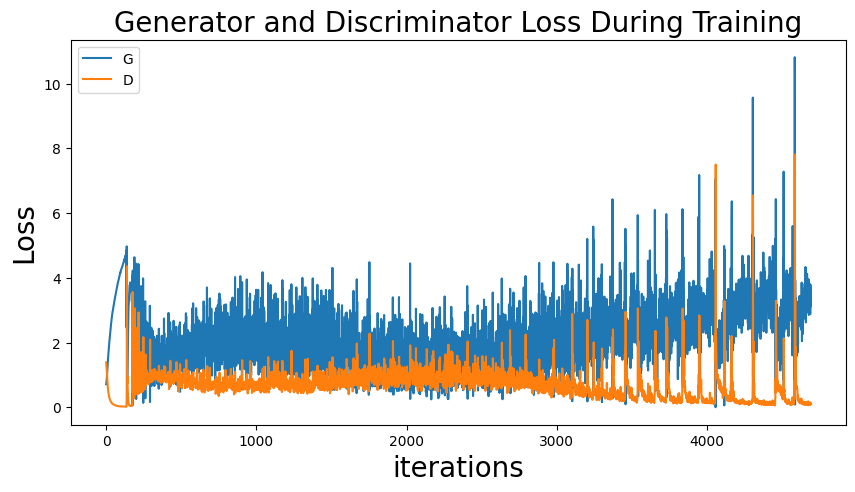

In [24]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training", fontsize=20)
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations", fontsize=20)
plt.ylabel("Loss", fontsize=20)
plt.legend()
plt.show()


In [25]:
# this is not for training, but for generating images after trained.
# generate fixed noise (fixed_z_) and fixed labels (fixed_y_label-)
# fixed_z_: 100 random vectors (z), each to generate one image
#           shape [100,100,1,1],
#           batch size =100, channel =100 (vector z), feature map:1x1
#
# fixed_y_label_: 100 one-hot vectors, each vector has 10 elements
#                 the one-hot vector for each digit repeats 10 times
#                 shape [100,10,1,1],
#                 batch size=100, channel=10 (one-hot vector)
#                 feature map: 1x1

temp_z_ = torch.randn(10, 100)
fixed_z_ = temp_z_
fixed_y_ = torch.zeros(10,1)

for i in range(9):
    fixed_z_ = torch.cat([fixed_z_, temp_z_], 0)
    temp = torch.ones(10, 1) + i
    fixed_y_ = torch.cat([fixed_y_, temp], 0)

fixed_z_=fixed_z_.view(-1,100,1,1)

fixed_y_label_ = torch.zeros(100,10)
fixed_y_label_.scatter_(1, fixed_y_.type(torch.LongTensor), 1)
fixed_y_label_ = fixed_y_label_.view(-1, 10, 1, 1)

fixed_z_ = fixed_z_.to(device)
fixed_y_label_ = fixed_y_label_.to(device)
#print(fixed_z_.shape, fixed_y_label_.shape)

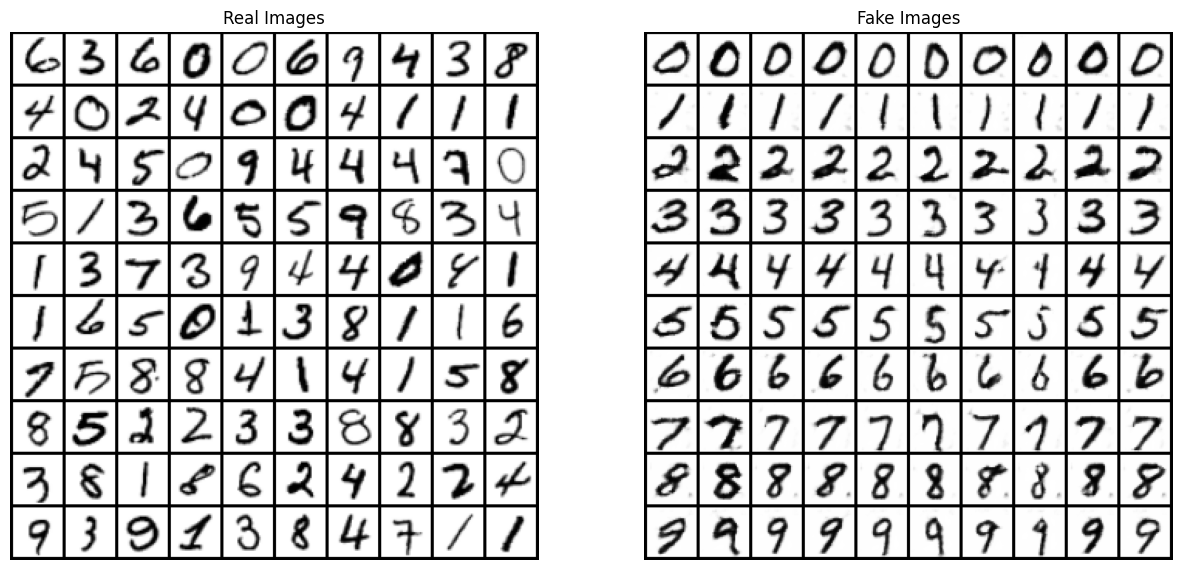

In [26]:
with torch.no_grad():
  fake = Gnet(fixed_z_, fixed_y_label_).detach().cpu()
img = vutils.make_grid(1-fake, padding=2, nrow=10, normalize=True)

real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(1-real_batch[0].to(device)[:100], padding=2, nrow=10,normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img,(1,2,0)))
plt.show()
